#*County Health Status Profiles: State of California*
-----
An Analytical Overview of Public Health Trends








#Project Objective


--------











 In this project,I am performing an end-to-end data analytics workflow on a healthstatus profile dataset using python in Google colab Notebook.The objective is to understand Health_Indicator_Desc ,Strata,County and Denominator_Total.I will follow a structured approach starting from data loanding.Then data cleaning and preprocessing,followed by exploratory data anaysis (EDA),visualization, and finally insight generation.






#About data

---


County Health Status Profiles is an annually published report for the State of California by the California Department of Public Health in collaboration with the California Conference of Local Health Officers. Health indicators are measured for 58 counties and California statewide that can be directly compared to national standards and populations of similar composition. Where available, the measurements are ranked and compared with target rates established for Healthy People National Objectives. For tables where the health indicator denominator and numerator are derived from the same data source, the denominator excludes records for which the health indicator data is missing and unable to be imputed. For more information see the

Before starting any data analysis project.I first import the required python libraries.These libraries provide the tools needed for data handling ,numercal computation and visualization.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pandas is used to load and manipulate tabular data.

Numpy is used to for numerical operations.

matplotlib and seaborn and plotly are used to create visualizations.

Importing all libraries at the beginning ensures consistency and avoids repetition later in the notebook.


##1 *Data Loading and Initial Overview*

In [79]:
#data loading
df = pd.read_csv('/content/drive/MyDrive/final project/County Health Status Profiles.csv')

In [80]:
#get number of rows and cloums
df.shape

(2183, 30)

In this step, I check how many rows and cloums are present in the dataset. Each rows represent year, Each colums represent an attribute related to the Publication_Year, Health_Indicator_Desc, County . This step is important to confirm that the dataset meets the project requirement of having a sufficient number of records and features.

In [81]:
df.head()

,Publication_Year,Table,Health_Indicator_Desc,Strata,Strata_Name,County,Rank_Order,Denominator_Total,Denominator_Average,Denominator_Label,...,Lower_Confidence_Limit,Upper_Confidence_Limit,Healthy_People_Decade,Healthy_People_Objective_Number,Healthy_People_Objective_Target,Healthy_People_Objective_Met,Denominator_Annotation_Code,Numerator_Annotation_Code,Rates_Annotation_Code,Annotation_Desc
0,2025,1,Deaths Due to All Causes,Total Population,Total Population,Santa Clara,1.0,1987898.0,1987898.0,Population,...,436.2,445.7,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,Deaths Due to All Causes,Total Population,Total Population,San Mateo,2.0,777635.0,777635.0,Population,...,441.7,456.3,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,Deaths Due to All Causes,Total Population,Total Population,Marin,3.0,257795.0,257795.0,Population,...,452.4,476.5,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,Deaths Due to All Causes,Total Population,Total Population,San Francisco,4.0,897416.0,897416.0,Population,...,502.4,517.0,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,Deaths Due to All Causes,Total Population,Total Population,Alameda,5.0,1689538.0,1689538.0,Population,...,534.3,546.1,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After loading the dataset,it is important to verify that the data has been correctly.I display the first five rows of the dataset to visually confirm the struture and values.

In [82]:
#get summary of dataset structure
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Publication_Year                 2183 non-null   int64  
 1   Table                            2183 non-null   object 
 2   Health_Indicator_Desc            2183 non-null   object 
 3   Strata                           2183 non-null   object 
 4   Strata_Name                      2183 non-null   object 
 5   County                           2183 non-null   object 
 6   Rank_Order                       1973 non-null   float64
 7   Denominator_Total                2100 non-null   float64
 8   Denominator_Average              2100 non-null   float64
 9   Denominator_Label                2183 non-null   object 
 10  Denominator_Year_Period          2183 non-null   object 
 11  Numerator_Total                  2013 non-null   float64
 12  Numerator_Average   

Disply descriptive statistacs for all numerical columns.

In [83]:
#get statistical summary of numeric colums
df .describe()


,Publication_Year,Rank_Order,Denominator_Total,Denominator_Average,Numerator_Total,Numerator_Average,Rate_Multiplier,Rate/Percentage,Age-Adjusted_Rate,Lower_Confidence_Limit,Upper_Confidence_Limit,Healthy_People_Decade,Healthy_People_Objective_Target,Denominator_Annotation_Code,Numerator_Annotation_Code,Rates_Annotation_Code
count,2183.0,1973.000000,2.100000e+03,2.100000e+03,2.013000e+03,1954.000000,2183.000000,1886.000000,1111.000000,1886.000000,1886.000000,2183.0,1357.000000,83.000000,170.0,544.000000
mean,2025.0,27.765839,8.469194e+05,8.423254e+05,6.187077e+03,1689.318117,73145.945946,99.170944,68.127093,77.046129,95.510445,2030.0,24.030435,2.421687,1.0,2.829044
std,0.0,16.221118,4.074211e+06,4.074716e+06,5.175796e+04,14347.374221,44136.419122,202.394963,160.127145,157.546700,172.176962,0.0,29.332911,0.912254,0.0,1.295339
min,2025.0,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,100.000000,0.500000,0.700000,0.000000,1.600000,2030.0,1.400000,1.000000,1.0,1.000000
25%,2025.0,14.000000,1.118650e+04,6.658000e+03,3.400000e+01,11.000000,1000.000000,12.300000,12.700000,7.625000,14.100000,2030.0,5.000000,1.000000,1.0,1.000000
50%,2025.0,27.000000,6.402300e+04,6.212400e+04,1.720000e+02,52.500000,100000.000000,28.100000,21.500000,17.600000,29.700000,2030.0,10.900000,3.000000,1.0,3.000000
75%,2025.0,41.000000,3.925610e+05,3.914990e+05,9.580000e+02,279.300000,100000.000000,81.925000,40.800000,68.975000,84.575000,2030.0,33.400000,3.000000,1.0,4.000000
max,2025.0,58.000000,4.014600e+07,4.014600e+07,1.275904e+06,348870.000000,100000.000000,1903.900000,1030.400000,1868.300000,1939.500000,2030.0,122.700000,3.000000,1.0,4.000000


Here, I generate a statistical summary of numerical columns. This provides insight into mean,minimum,maximum and distribution of values.

In [84]:
df.columns

Index(['Publication_Year', 'Table', 'Health_Indicator_Desc', 'Strata',
       'Strata_Name', 'County', 'Rank_Order', 'Denominator_Total',
       'Denominator_Average', 'Denominator_Label', 'Denominator_Year_Period',
       'Numerator_Total', 'Numerator_Average', 'Numerator_Label',
       'Numerator_Year_Period', 'Rate_Multiplier', 'Rate/Percentage',
       'Rate/Percentage_Label', 'Age-Adjusted_Rate', 'Age-Adjusted_Rate_Label',
       'Lower_Confidence_Limit', 'Upper_Confidence_Limit',
       'Healthy_People_Decade', 'Healthy_People_Objective_Number',
       'Healthy_People_Objective_Target', 'Healthy_People_Objective_Met',
       'Denominator_Annotation_Code', 'Numerator_Annotation_Code',
       'Rates_Annotation_Code', 'Annotation_Desc'],
      dtype='object')

In [85]:
#data type of each colums
df .dtypes

,0
Publication_Year,int64
Table,object
Health_Indicator_Desc,object
Strata,object
Strata_Name,object
County,object
Rank_Order,float64
Denominator_Total,float64
Denominator_Average,float64
Denominator_Label,object


Before performing any analysis,it is very important to understand what each column represent. This ensures correct interpretation of result.

In [86]:
df['Health_Indicator_Desc']

,Health_Indicator_Desc
0,Deaths Due to All Causes
1,Deaths Due to All Causes
2,Deaths Due to All Causes
3,Deaths Due to All Causes
4,Deaths Due to All Causes
...,...
2178,Persons under 18 Years Old in Poverty
2179,Persons under 18 Years Old in Poverty
2180,Persons under 18 Years Old in Poverty
2181,Persons under 18 Years Old in Poverty


count how many times each unique value appears in a column

In [88]:
df['County']

,County
0,Santa Clara
1,San Mateo
2,Marin
3,San Francisco
4,Alameda
...,...
2178,Merced
2179,Alpine
2180,Imperial
2181,Modoc


 ### 2 *Data Pre-processing*


In [89]:
#identified null values using isnull()sum()
df .isnull().sum()

,0
Publication_Year,0
Table,0
Health_Indicator_Desc,0
Strata,0
Strata_Name,0
County,0
Rank_Order,210
Denominator_Total,83
Denominator_Average,83
Denominator_Label,0


Healthcare data may contain missing values.missing data can affect analysis accuracy.So i first check how many missing values are present in colums.

In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df['Table'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22F', '22M',
       '23', '23C', '23F', '23M', '24A', '24B', '24C', '24D', '24E', '25',
       '26', '27A', '27B', '29'], dtype=object)

so the column isn't consistently formatted some table identifiers have letters attached.

In [92]:
df['Table']=df['Table'].replace("22F",22)
df['Table']=df['Table'].replace("22M",22)
df['Table']=df['Table'].replace("23C",23)
df['Table']=df['Table'].replace("23F",23)
df['Table']=df['Table'].replace("23M",23)
df['Table']=df['Table'].replace("24A",24)
df['Table']=df['Table'].replace("24B",24)
df['Table']=df['Table'].replace("24C",24)
df['Table']=df['Table'].replace("24E",24)
df['Table']=df['Table'].replace("24D",24)
df['Table']=df['Table'].replace("27A",27)
df['Table']=df['Table'].replace("27B",27)
df['Table'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', 22, '23', 23,
       24, '25', '26', 27, '29'], dtype=object)

so they.re essentially removing the letters suffixes and grouping those records under the main table number.

In [93]:
df.drop(columns=['Healthy_People_Objective_Number','Numerator_Annotation_Code'],inplace=True)

In [94]:
df.drop(columns=['Healthy_People_Objective_Target','Rates_Annotation_Code'],inplace=True)

In [95]:
df.drop(columns=['Age-Adjusted_Rate','Age-Adjusted_Rate_Label'],inplace=True)

In [96]:
df.drop(columns=['Healthy_People_Objective_Met','Denominator_Annotation_Code','Annotation_Desc'],inplace=True)

Columns Dropped

Healthy_People_Objective_Number
Numerator_Annotation_Code
Healthy_People_Objective_Target
Rates_Annotation_Code
Age-Adjusted_Rate
Age-Adjusted_Rate_Label
Healthy_People_Objective_Met
Denominator_Annotation_Code
Annotation_Desc

These columns had a substantial amount of missing data (many with over 800 or even over 2000 missing entries out of 2183 total rows), making them unreliable for robust analysis without extensive imputation that could introduce bias. Furthermore, some of these, like the Annotation_Code and Annotation_Desc columns, often provide metadata or context that is less critical for the primary objective of analyzing Health_Indicator_Desc, Strata, County, and Denominator_Total directly. Age-Adjusted_Rate and its label, while important in some epidemiological contexts, also had a high number of missing values, making it difficult to use consistently across the dataset for this initial exploration.

By removing these columns, we reduce noise, simplify the dataset, and focus on the more complete and relevant features for our analysis.

In [97]:
df.fillna("0", inplace=True)

/tmp/ipykernel_498/4235612803.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



In [98]:
df['Denominator_Total']=pd.to_numeric(df['Denominator_Total'],errors='coerce')
df['Denominator_Total'].describe()

,Denominator_Total
count,2.183000e+03
mean,8.147187e+05
std,3.999254e+06
min,0.000000e+00
25%,7.076500e+03
50%,5.435000e+04
75%,2.886010e+05
max,4.014600e+07


* This line is used to convert the data type of the Denominator_Total column in your DataFrame (df) to a numeric type (like float or int).
* pd.to_numeric() is a pandas function specifically designed for this purpose.
* The errors='coerce' argument is very important here. It tells pandas that if it encounters any value in the Denominator_Total column that cannot be converted into a number , it should replace that value with NaN . Without errors='coerce', if there were non-numeric values, the code would raise an error and stop execution.
includes:
* After the Denominator_Total column has been successfully converted to a numeric type, this line generates and displays a statistical summary for that column.
* The .describe() method provides key descriptive statistics such as count, mean, standard deviation, minimum, maximum, and the quartile values (25th, 50th, and 75th percentiles).

In [99]:
df['Denominator_Average']=pd.to_numeric(df['Denominator_Average'],errors='coerce')
df['Denominator_Average'].describe()

,Denominator_Average
count,2.183000e+03
mean,8.102993e+05
std,3.999714e+06
min,0.000000e+00
25%,4.164500e+03
50%,4.981700e+04
75%,2.886010e+05
max,4.014600e+07


* This line converts the Denominator_Average column in DataFrame to a numeric data type.
* pd.to_numeric() is the pandas function used to perform this conversion.
* The errors='coerce' argument is crucial here: it instructs pandas to replace any values in the Denominator_Average column that cannot be converted into a number with NaN . This prevents the code from crashing due to non-numeric entries and allows the conversion to complete.
* Once the Denominator_Average column has been successfully converted to a numeric type, this line generates and displays a statistical summary for that column.
* The .describe() method provides key descriptive statistics such as the count of non-null values, mean, standard deviation, minimum value, maximum value, and the values for the 25th, 50th (median), and 75th percentiles.

In [100]:
df['Numerator_Total']=pd.to_numeric(df['Numerator_Total'],errors='coerce')
df['Numerator_Total'].describe()

,Numerator_Total
count,2.183000e+03
mean,5.705262e+03
std,4.972850e+04
min,0.000000e+00
25%,2.100000e+01
50%,1.350000e+02
75%,8.125000e+02
max,1.275904e+06


* This line is used to convert the data type of the Numerator_Total column in DataFrame (df) to a numeric type (like float or int).
* pd.to_numeric() is a pandas function specifically designed for this purpose.
* The errors='coerce' argument is very important here. It tells pandas that if it encounters any value in the Numerator_Total column that cannot be converted into a number, it should replace that value with NaN . Without errors='coerce', if there were non-numeric values, the code would raise an error and stop execution.
* After ensuring the Numerator_Total column is numeric , this line calculates and displays descriptive statistics for that column.
* The .describe() method provides a summary of the central tendency, dispersion, and shape of the distribution of the numeric data. This typically includes:
count: The number of non-null values.
mean: The average value.
std: The standard deviation (a measure of spread).
min: The minimum value.
25%: The first quartile (25th percentile).
50%: The median (50th percentile or second quartile).
75%: The third quartile (75th percentile).
max: The maximum value.

In [101]:
df['Numerator_Average']=pd.to_numeric(df['Numerator_Average'],errors='coerce')
df['Numerator_Average'].describe()

,Numerator_Average
count,2183.000000
mean,1512.106093
std,13583.506913
min,0.000000
25%,5.300000
50%,38.300000
75%,225.300000
max,348870.000000


* This line converts the Numerator_Average column in DataFrame (df) to a numeric data type.
* pd.to_numeric() is the pandas function used to perform this conversion.
* The errors='coerce' argument is crucial here: it instructs pandas to replace any values in the Numerator_Average column that cannot be converted into a number with NaN . This prevents the code from crashing due to non-numeric entries and allows the conversion to complete.
* Once the Numerator_Average column has been successfully converted to a numeric type, this line generates and displays a statistical summary for that column.
* The .describe() method provides key descriptive statistics such as the count of non-null values, mean, standard deviation, minimum value, maximum value, and the values for the 25th, 50th (median), and 75th percentiles.

#outliers

In [102]:
Q1 = df['Denominator_Total'].quantile(0.25)
Q3 = df['Denominator_Total'].quantile(0.75)
IQR = Q3 - Q1

Outliers are data points that significantly differ from other observations. Identifying them is crucial as they can skew analysis results and statistical models. Here, I'll define a function to detect outliers using the Interquartile Range (IQR) method.
* Q1 = df['Denominator_Total'].quantile(0.25): This line calculates the First Quartile (Q1) for the Denominator_Total column. Q1 represents the value below which 25% of the data falls. In simpler terms, it's the 25th percentile.
* Q3 = df['Denominator_Total'].quantile(0.75): This line calculates the Third Quartile (Q3) for the Denominator_Total column. Q3 represents the value below which 75% of the data falls (or above which 25% of the data lies). It's the 75th percentile.

In [103]:
IQR = Q3 - Q1
IQR

np.float64(281524.5)

Interquartile Range (IQR): This value represents the range within which the central 50% of your Denominator_Total data lies. It's calculated as the difference between the 75th percentile (Q3) and the 25th percentile (Q1).
Meaning of 281,524.5: For the Denominator_Total values in your dataset, the middle half of the data points are spread across a range of approximately 281,524.5 units. A larger IQR suggests a greater spread or variability in the central portion of the data, while a smaller IQR indicates data points are more clustered around the median.
Purpose: You then used this IQR value to define lower_limit and upper_limit (as Q1 - 1.5*IQR and Q3 + 1.5*IQR respectively) to identify outliers in the Denominator_Total column. Data points falling outside these limits are considered outlier

In [104]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(-415210.25), np.float64(710887.75))

lower_limit = Q1 - 1.5*IQR

This formula defines the lower bound for what is considered 'normal' data. Any data point in Denominator_Total that falls below this lower_limit is identified as a lower outlier.
* lower_limit is np.float64(-415210.25). This means any Denominator_Total value less than approximately -415,210.25 would be flagged as a lower outlier.

upper_limit = Q3 + 1.5*IQR:

* This formula defines the upper bound for what is considered 'normal' data. Any data point in Denominator_Total that falls above this upper_limit is identified as an upper outlier.
* upper_limit is np.float64(710887.75). This means any Denominator_Total value greater than approximately 710,887.75 would be flagged as an upper outlier.

#with outliers

In [105]:
df[(df.Denominator_Total<lower_limit)|(df.Denominator_Total>upper_limit)]

,Publication_Year,Table,Health_Indicator_Desc,Strata,Strata_Name,County,Rank_Order,Denominator_Total,Denominator_Average,Denominator_Label,...,Numerator_Total,Numerator_Average,Numerator_Label,Numerator_Year_Period,Rate_Multiplier,Rate/Percentage,Rate/Percentage_Label,Lower_Confidence_Limit,Upper_Confidence_Limit,Healthy_People_Decade
0,2025,1,Deaths Due to All Causes,Total Population,Total Population,Santa Clara,1.0,1987898.0,1987898.0,Population,...,33716.0,11238.7,Deaths,2021-2023,100000,565.4,Crude Death Rate,436.2,445.7,2030
1,2025,1,Deaths Due to All Causes,Total Population,Total Population,San Mateo,2.0,777635.0,777635.0,Population,...,15300.0,5100.0,Deaths,2021-2023,100000,655.8,Crude Death Rate,441.7,456.3,2030
3,2025,1,Deaths Due to All Causes,Total Population,Total Population,San Francisco,4.0,897416.0,897416.0,Population,...,19513.0,6504.3,Deaths,2021-2023,100000,724.8,Crude Death Rate,502.4,517.0,2030
4,2025,1,Deaths Due to All Causes,Total Population,Total Population,Alameda,5.0,1689538.0,1689538.0,Population,...,33129.0,11043.0,Deaths,2021-2023,100000,653.6,Crude Death Rate,534.3,546.1,2030
6,2025,1,Deaths Due to All Causes,Total Population,Total Population,Orange,7.0,3218111.0,3218111.0,Population,...,71338.0,23779.3,Deaths,2021-2023,100000,738.9,Crude Death Rate,566.0,574.5,2030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,2025,24,"Infant Mortality, All Race/Ethnic Groups",Total Live Births,Total Live Births,CALIFORNIA,0,1214628.0,404876.0,Live Births,...,4444.0,1481.3,Infant Deaths,2020-2022,1000,3.7,Birth Cohort Infant Death Rate,3.6,3.8,2030
1923,2025,25,Low Birthweight Infants,Total Live Births,Total Live Births,CALIFORNIA,0,1240125.0,413375.0,Live Births,...,91972.0,30657.3,Low Birthweight Number,2021-2023,100,7.4,Low Birthweight Percent,7.4,7.5,2030
1972,2025,26,"Births to Adolescent Mothers, 15 to 19 Years Old",Age * Sex,15-19 Years Old * Female,CALIFORNIA,0,1359286.0,1359286.0,Female Population 15-19 Years Old,...,36314.0,12104.7,Live Births,2021-2023,1000,8.9,Age-Specific Birth Rate,8.8,9.0,2030
2024,2025,27,Prenatal Care Begun during the First Trimester...,Total Live Births,Total Live Births,CALIFORNIA,0,1210247.0,403415.7,Live Births,...,1046610.0,348870.0,First Trimester Prenatal Care Number,2021-2023,100,86.5,First Trimester Prenatal Care Percent,86.3,86.6,2030


* In summary, this code creates a new DataFrame containing only those rows where the Denominator_Total is either below the calculated lower_limit or above the calculated upper_limit. These are the 357 data points you identified as outliers in your earlier output.

#Without outliers


In [106]:
df_no_outlier = df[(df.Denominator_Total>lower_limit)&(df.Denominator_Total<upper_limit)]
df_no_outlier

,Publication_Year,Table,Health_Indicator_Desc,Strata,Strata_Name,County,Rank_Order,Denominator_Total,Denominator_Average,Denominator_Label,...,Numerator_Total,Numerator_Average,Numerator_Label,Numerator_Year_Period,Rate_Multiplier,Rate/Percentage,Rate/Percentage_Label,Lower_Confidence_Limit,Upper_Confidence_Limit,Healthy_People_Decade
2,2025,1,Deaths Due to All Causes,Total Population,Total Population,Marin,3.0,257795.0,257795.0,Population,...,6550.0,2183.3,Deaths,2021-2023,100000,846.9,Crude Death Rate,452.4,476.5,2030
5,2025,1,Deaths Due to All Causes,Total Population,Total Population,Mono,6.0,13898.0,13898.0,Population,...,212.0,70.7,Deaths,2021-2023,100000,508.5,Crude Death Rate,456.0,635.4,2030
7,2025,1,Deaths Due to All Causes,Total Population,Total Population,Monterey,8.0,447300.0,447300.0,Population,...,8974.0,2991.3,Deaths,2021-2023,100000,668.8,Crude Death Rate,561.2,585.2,2030
9,2025,1,Deaths Due to All Causes,Total Population,Total Population,Santa Cruz,10.0,276024.0,276024.0,Population,...,5981.0,1993.7,Deaths,2021-2023,100000,722.3,Crude Death Rate,561.9,592.3,2030
10,2025,1,Deaths Due to All Causes,Total Population,Total Population,Sonoma,11.0,502886.0,502886.0,Population,...,13594.0,4531.3,Deaths,2021-2023,100000,901.1,Crude Death Rate,571.0,591.5,2030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2178,2025,29,Persons under 18 Years Old in Poverty,Age,Under 18 Years Old,Merced,54.0,0.0,0.0,Population under 18 Years Old,...,21234.0,0.0,Number in Poverty,2022,100,26.0,Percent in Poverty,22.2,29.8,2030
2179,2025,29,Persons under 18 Years Old in Poverty,Age,Under 18 Years Old,Alpine,55.0,0.0,0.0,Population under 18 Years Old,...,50.0,0.0,Number in Poverty,2022,100,26.6,Percent in Poverty,16.5,36.7,2030
2180,2025,29,Persons under 18 Years Old in Poverty,Age,Under 18 Years Old,Imperial,56.0,0.0,0.0,Population under 18 Years Old,...,13642.0,0.0,Number in Poverty,2022,100,27.5,Percent in Poverty,22.5,32.5,2030
2181,2025,29,Persons under 18 Years Old in Poverty,Age,Under 18 Years Old,Modoc,57.0,0.0,0.0,Population under 18 Years Old,...,425.0,0.0,Number in Poverty,2022,100,28.0,Percent in Poverty,17.8,38.2,2030


Remove outliers

# 3  *Exploratory Data Analysis*

In [107]:
df.describe()

,Publication_Year,Denominator_Total,Denominator_Average,Numerator_Total,Numerator_Average,Rate_Multiplier,Healthy_People_Decade
count,2183.0,2.183000e+03,2.183000e+03,2.183000e+03,2183.000000,2183.000000,2183.0
mean,2025.0,8.147187e+05,8.102993e+05,5.705262e+03,1512.106093,73145.945946,2030.0
std,0.0,3.999254e+06,3.999714e+06,4.972850e+04,13583.506913,44136.419122,0.0
min,2025.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,100.000000,2030.0
25%,2025.0,7.076500e+03,4.164500e+03,2.100000e+01,5.300000,1000.000000,2030.0
50%,2025.0,5.435000e+04,4.981700e+04,1.350000e+02,38.300000,100000.000000,2030.0
75%,2025.0,2.886010e+05,2.886010e+05,8.125000e+02,225.300000,100000.000000,2030.0
max,2025.0,4.014600e+07,4.014600e+07,1.275904e+06,348870.000000,100000.000000,2030.0


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Publication_Year         2183 non-null   int64  
 1   Table                    2183 non-null   object 
 2   Health_Indicator_Desc    2183 non-null   object 
 3   Strata                   2183 non-null   object 
 4   Strata_Name              2183 non-null   object 
 5   County                   2183 non-null   object 
 6   Rank_Order               2183 non-null   object 
 7   Denominator_Total        2183 non-null   float64
 8   Denominator_Average      2183 non-null   float64
 9   Denominator_Label        2183 non-null   object 
 10  Denominator_Year_Period  2183 non-null   object 
 11  Numerator_Total          2183 non-null   float64
 12  Numerator_Average        2183 non-null   float64
 13  Numerator_Label          2183 non-null   object 
 14  Numerator_Year_Period   

In [109]:
df.isnull().sum()

,0
Publication_Year,0
Table,0
Health_Indicator_Desc,0
Strata,0
Strata_Name,0
County,0
Rank_Order,0
Denominator_Total,0
Denominator_Average,0
Denominator_Label,0


After identifying the columns with missing values, I will now fill them using an appropriate strategy. For numerical columns, filling with the mean is a common approach to retain the central tendency of the data.

In [110]:
df.groupby('Health_Indicator_Desc')['Denominator_Total'].sum()

,Denominator_Total
Health_Indicator_Desc,
Adequate/Adequate Plus Prenatal Care (Adequacy of Prenatal Care Utilization Index),2404818.0
Asian/Pacific Islander Infant Mortality,339303.0
"Births to Adolescent Mothers, 15 to 19 Years Old",2718572.0
Black Infant Mortality,118160.0
Deaths Due to Accidents (Unintentional Injuries),80292006.0
Deaths Due to All Cancers,80292006.0
Deaths Due to All Causes,80292006.0
Deaths Due to Alzheimer's Disease,80292006.0
Deaths Due to Cerebrovascular Disease (Stroke),80292006.0


* df.groupby('Health_Indicator_Desc'): This part groups the DataFrame df by the unique values found in the 'Health_Indicator_Desc' column. Imagine it's organizing your data into separate mini-tables, one for each distinct health indicator.
* ['Denominator_Total']: After grouping, this selects the 'Denominator_Total' column from each of these groups.
* .sum(): This performs a sum operation on the 'Denominator_Total' column for each group. So, for every unique Health_Indicator_Desc, it adds up all the corresponding Denominator_Total values.

In [111]:
df.groupby('Health_Indicator_Desc')['Numerator_Total'].sum()

,Numerator_Total
Health_Indicator_Desc,
Adequate/Adequate Plus Prenatal Care (Adequacy of Prenatal Care Utilization Index),1738871.0
Asian/Pacific Islander Infant Mortality,835.0
"Births to Adolescent Mothers, 15 to 19 Years Old",72612.0
Black Infant Mortality,874.0
Deaths Due to Accidents (Unintentional Injuries),126254.0
Deaths Due to All Cancers,360420.0
Deaths Due to All Causes,1882950.0
Deaths Due to Alzheimer's Disease,100564.0
Deaths Due to Cerebrovascular Disease (Stroke),109350.0


Univariate Analysis

In [112]:
df['Numerator_Total'].describe()

,Numerator_Total
count,2.183000e+03
mean,5.705262e+03
std,4.972850e+04
min,0.000000e+00
25%,2.100000e+01
50%,1.350000e+02
75%,8.125000e+02
max,1.275904e+06


In [113]:
df['Healthy_People_Decade'].value_counts()

,count
Healthy_People_Decade,
2030,2183


In [114]:
df['Denominator_Total'].describe()

,Denominator_Total
count,2.183000e+03
mean,8.147187e+05
std,3.999254e+06
min,0.000000e+00
25%,7.076500e+03
50%,5.435000e+04
75%,2.886010e+05
max,4.014600e+07


Bivariate Analysis

In [117]:
df[['Denominator_Total','Numerator_Total']].corr()

,Denominator_Total,Numerator_Total
Denominator_Total,1.000000,0.250971
Numerator_Total,0.250971,1.000000


In [118]:
df.groupby('Health_Indicator_Desc')['Denominator_Total'].mean()

,Denominator_Total
Health_Indicator_Desc,
Adequate/Adequate Plus Prenatal Care (Adequacy of Prenatal Care Utilization Index),4.075963e+04
Asian/Pacific Islander Infant Mortality,5.750898e+03
"Births to Adolescent Mothers, 15 to 19 Years Old",4.607749e+04
Black Infant Mortality,2.002712e+03
Deaths Due to Accidents (Unintentional Injuries),1.360881e+06
Deaths Due to All Cancers,1.360881e+06
Deaths Due to All Causes,1.360881e+06
Deaths Due to Alzheimer's Disease,1.360881e+06
Deaths Due to Cerebrovascular Disease (Stroke),1.360881e+06


In [119]:
df.groupby('Rank_Order')['Denominator_Total'].mean()

,Denominator_Total
Rank_Order,
1.0,1.626734e+05
2.0,3.788152e+05
3.0,2.724770e+05
4.0,2.596539e+05
5.0,2.137548e+05
6.0,5.740389e+05
7.0,5.631127e+05
8.0,3.360417e+05
9.0,6.842575e+05


multivariate Analysis

In [120]:
df[
    ['Denominator_Total',
     'Numerator_Total',
     'Lower_Confidence_Limit',
     'Upper_Confidence_Limit']
].corr()

,Denominator_Total,Numerator_Total,Lower_Confidence_Limit,Upper_Confidence_Limit
Denominator_Total,1.000000,0.250971,0.041113,0.021119
Numerator_Total,0.250971,1.000000,0.124029,0.104825
Lower_Confidence_Limit,0.041113,0.124029,1.000000,0.982757
Upper_Confidence_Limit,0.021119,0.104825,0.982757,1.000000


In [121]:
df.groupby(
    ['Health_Indicator_Desc', 'Rank_Order']
)['Denominator_Total'].mean()

Health_Indicator_Desc                                                               Rank_Order
Adequate/Adequate Plus Prenatal Care (Adequacy of Prenatal Care Utilization Index)  1.0            1304.000000
                                                                                    2.0            6857.000000
                                                                                    3.0            2284.000000
                                                                                    4.0           16372.000000
                                                                                    5.0           19395.000000
                                                                                                      ...     
White Infant Mortality                                                              23.0           5496.000000
                                                                                    24.0          12437.000000
                                                                                    25.0           3261.000000
                                                                                    26.0           5990.000000
                                                                                    0             11610.757576
Name: Denominator_Total, Length: 2010, dtype: float64

In [122]:
df.groupby(
    ['County', 'Health_Indicator_Desc']
)['Numerator_Total'].mean()

County   Health_Indicator_Desc                                                                
Alameda  Adequate/Adequate Plus Prenatal Care (Adequacy of Prenatal Care Utilization Index)       30994.0
         Asian/Pacific Islander Infant Mortality                                                     47.0
         Births to Adolescent Mothers, 15 to 19 Years Old                                           912.0
         Black Infant Mortality                                                                      32.0
         Deaths Due to Accidents (Unintentional Injuries)                                          1989.0
                                                                                                   ...   
Yuba     Reported Incidence of Primary and Secondary Syphilis among Females 15 to 44 Years Old       24.0
         Reported Incidence of Primary and Secondary Syphilis among Males All Ages                   66.0
         Reported Incidence of Tuberculosis                                                           6.0
         Reported Prevalence of Persons Living with HIV/AIDS among Ages 13 Years and Older          320.0
         White Infant Mortality                                                                       0.0
Name: Numerator_Total, Length: 2183, dtype: float64

#groupby

In [123]:
# Average Health_status
Health_status = df.groupby('Health_Indicator_Desc')['Denominator_Average'].mean()
print(Health_status)

Health_Indicator_Desc
Adequate/Adequate Plus Prenatal Care (Adequacy of Prenatal Care Utilization Index)       1.358654e+04
Asian/Pacific Islander Infant Mortality                                                  1.916964e+03
Births to Adolescent Mothers, 15 to 19 Years Old                                         4.607749e+04
Black Infant Mortality                                                                   6.675712e+02
Deaths Due to Accidents (Unintentional Injuries)                                         1.360881e+06
Deaths Due to All Cancers                                                                1.360881e+06
Deaths Due to All Causes                                                                 1.360881e+06
Deaths Due to Alzheimer's Disease                                                        1.360881e+06
Deaths Due to Cerebrovascular Disease (Stroke)                                           1.360881e+06
Deaths Due to Chronic Liver Disease and Cirrhosis           

#Correlation

In [124]:
# Correlation matrix for key health indicators
corr_matrix = df[['Denominator_Total','Numerator_Total','Lower_Confidence_Limit','Upper_Confidence_Limit']].corr()
print(corr_matrix)

                        Denominator_Total  Numerator_Total  \
Denominator_Total                1.000000         0.250971   
Numerator_Total                  0.250971         1.000000   
Lower_Confidence_Limit           0.041113         0.124029   
Upper_Confidence_Limit           0.021119         0.104825   

                        Lower_Confidence_Limit  Upper_Confidence_Limit  
Denominator_Total                     0.041113                0.021119  
Numerator_Total                       0.124029                0.104825  
Lower_Confidence_Limit                1.000000                0.982757  
Upper_Confidence_Limit                0.982757                1.000000  


The correlation matrix is used to understand the strength and direction of the liner relationship between key health indicators
The correlation analysis shows a very strong positive correlation'(0.98) between the lower and upper confidence limits,while the relationship between denominator and numerator total is relatively weak (0.250)

#Pivot_Table

In [125]:
#Health
Health_Indicator_Desc = pd.pivot_table(df,
                                values='Denominator_Total',
                                index='Health_Indicator_Desc',
                                columns='Rank_Order',
                                aggfunc='mean')
print(Health_Indicator_Desc)

Rank_Order                                                1.0        2.0  \
Health_Indicator_Desc                                                      
Adequate/Adequate Plus Prenatal Care (Adequacy ...     1304.0     6857.0   
Asian/Pacific Islander Infant Mortality                 715.0      530.0   
Births to Adolescent Mothers, 15 to 19 Years Old      12199.0     7971.0   
Black Infant Mortality                                  211.0      130.0   
Deaths Due to Accidents (Unintentional Injuries)     777635.0  1987898.0   
Deaths Due to All Cancers                             13898.0  1987898.0   
Deaths Due to All Causes                            1987898.0   777635.0   
Deaths Due to Alzheimer's Disease                      1139.0    19041.0   
Deaths Due to Cerebrovascular Disease (Stroke)         3077.0     1139.0   
Deaths Due to Chronic Liver Disease and Cirrhosis    777635.0   897416.0   
Deaths Due to Chronic Lower Respiratory Disease        1139.0  1987898.0   
Deaths Due t

Pivot Table (Health_Indicator_Desc by Rank_Order): The pivot table for Health_Indicator_Desc with Rank_Order as columns and the mean Denominator_Total as values provides a detailed view of how the average Denominator_Total varies for each health indicator across different rankings. For instance, 'Deaths Due to All Causes' shows a very high Denominator_Total at rank 1, but this value fluctuates significantly across different rank orders. Similarly, 'Persons under 18 Years Old in Poverty' consistently shows 0.0 for Denominator_Total across all rank orders, which might indicate a data collection or definition issue, or perhaps that the denominator for this indicator is captured differently. This table allows for comparison of the base populations associated with different health indicators at various county performance ranks.

#County summary

In [126]:
# County-
county_summary = df.groupby('County')[['Denominator_Total','Numerator_Total']].agg(['mean','median','std'])
print(county_summary.head())

           Denominator_Total                           Numerator_Total  \
                        mean      median           std            mean   
County                                                                   
Alameda         1.012444e+06   1689538.0  7.616622e+05     5974.162162   
Alpine          6.782162e+02      1139.0  5.218025e+02        3.378378   
Amador          2.273968e+04     38161.0  1.745468e+04      163.702703   
Butte           1.366443e+05    227736.0  1.026258e+05      967.567568   
CALIFORNIA      2.403420e+07  40146003.0  1.809929e+07   168315.081081   

                                    
             median            std  
County                              
Alameda       912.0   11415.961284  
Alpine          0.0      10.272269  
Amador         29.0     328.773720  
Butte         162.0    1950.805468  
CALIFORNIA  30376.0  330192.304963  


# 4 *Visualizations*

Univariate Analysis

In [127]:
fig = px.histogram(
    df,
    x='Denominator_Total',
    title='Distribution of Denominator Total'
)

fig.show()

Most Denominator_Total values are concentrated in the lower range,while a few observations have very high values.

Bivariate Analysis

In [128]:
fig = px.scatter(df,
                 x='Denominator_Total',
                 y='Numerator_Total',
                 title='Denominator vs Numerator')
fig.show()

The scatter plot shows the relationship between Denominator_Total and Numerator_Total.most observation are concetrated at lower values,while a few observation have very high values.The correlation of 0.250971 indicates a weak positive relationship between the two variables.

multivariate Analysis

In [129]:
fig = px.scatter(df,
                 x='Denominator_Total',
                 y='Numerator_Total',
                 color='Health_Indicator_Desc',
                 hover_data=['County', 'Rank_Order'],
                 title='Health Indicators by County')
fig.show()

The multivariate scatter plot analyzes the relationship between Denominator_Total and Numerator_Total across different health indicators and counties.Different colours represent different health indicators,while County and Rank_Order provide additional information when hovering over the point.The plot shows conconsiderable variation among health indicators,with most obervations concentrated at lower values and some obervations showing very high values.

Bar plot

In [130]:
counts = df['Health_Indicator_Desc'].value_counts().reset_index()
counts.columns = ['Health_Indicator_Desc', 'Count']

fig = px.bar(
    counts,
    x='Health_Indicator_Desc',
    y='Count',
    title='Frequency of Health Indicators',
    hover_data=['Count']
)

fig.update_xaxes(tickangle=45)
fig.show()

The bar chart shiows the frequency of each health indicator in the dataset.The height of each bar represents the number of records for that health indicator.
bar height :Frequency of that health indicator
Hover shows the exct count

Pie chart

In [131]:
counts = df['Health_Indicator_Desc'].value_counts().reset_index()
counts.columns = ['Health_Indicator_Desc', 'Count']

fig = px.pie(
    counts,
    names='Health_Indicator_Desc',
    values='Count',
    title='Health Indicator Distribution'
)

fig.show()

The pie chart shows the distribution of health indicators in the dataset.Each slice represents a health indicator,and the size of the slice represent the number of records associated with that indicator.

Line chart

In [132]:
rank_data = (
    df.groupby('Rank_Order')['Denominator_Total']
      .mean()
      .reset_index()
)

fig = px.line(
    rank_data,
    x='Rank_Order',
    y='Denominator_Total',
    markers=True,
    title='Average Denominator Total by Rank Order',
    labels={
        'Rank_Order': 'Rank Order',
        'Denominator_Total': 'Average Denominator Total'
    }
)

fig.show()

This line chart shows how the average Denominator_Total changes across different Rank_Order values.The average Denominator_Total is calculated for each rank and represented using a line chart.
Each point:Average denominator for that particular rank.
Line :shows how the average changes from one rank to another.

In [133]:
county_counts = df['County'].value_counts().reset_index()
county_counts.columns = ['County', 'Count']

fig = px.bar(
    county_counts,
    x='County',
    y='Count',
    title='Number of Records by County'
)

fig.update_xaxes(tickangle=45)
fig.show()

The bar chart shows the number of records available for each county in the california county health dataset.

box plot


In [134]:

fig = px.box(
    df,
    x='Health_Indicator_Desc',
    y='Denominator_Total',
    title='Denominator Total by Health Indicator',
    points='outliers'
)

fig.update_xaxes(tickangle=45)
fig.show()

The box plotcompares the distribution of Denominator_Total across different health indicators.it shows the median,spread,and possible outliers for each health indicator.


Subplots

In [135]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Denominator Total',
        'Numerator Total',
        'Lower Confidence Limit',
        'Upper Confidence Limit'
    )
)

fig.add_trace(
    go.Histogram(x=df['Denominator_Total'], name='Denominator'),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df['Numerator_Total'], name='Numerator'),
    row=1, col=2
)

fig.add_trace(
    go.Histogram(x=df['Lower_Confidence_Limit'], name='Lower Limit'),
    row=2, col=1
)

fig.add_trace(
    go.Histogram(x=df['Upper_Confidence_Limit'], name='Upper Limit'),
    row=2, col=2
)

fig.update_layout(
    title='Health Dataset Numerical Variables',
    height=700
)

fig.show()

This subplot displays the distributions of four numerical variables - Denominator Total,Numerator Total,lower confidence limit,and upper confidence limit in a single interactive figure.

In [138]:
fig = px.scatter(df, x='Denominator_Total', y='Health_Indicator_Desc', color='County',
                 title='Interactive Scatter Plot of Denominator Total vs. Health Indicator by County',
                 hover_data=['Numerator_Total', 'Strata_Name'])
fig.show()

This plot helps visualize the relationship between the total population or base (Denominator_Total) and different health indicators (Health_Indicator_Desc) across various counties, with interactive details on hover.

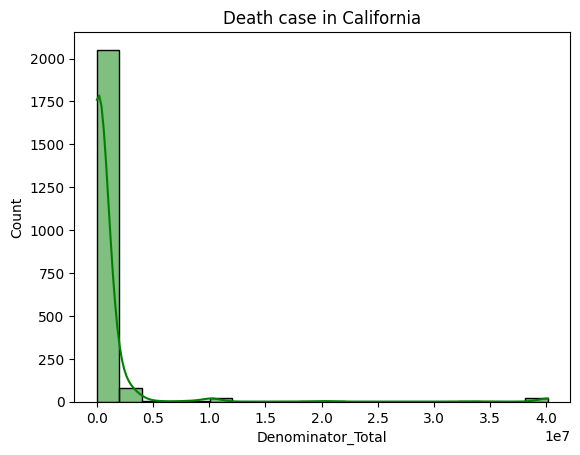

In [139]:
# county in California
sns.histplot(df['Denominator_Total'], bins=20, kde=True, color='green')
plt.title("Death case in California")
plt.show()


Green bars :show the nuumber of records within each range.

smooth line :shows the estimated distribution or shape of the data.


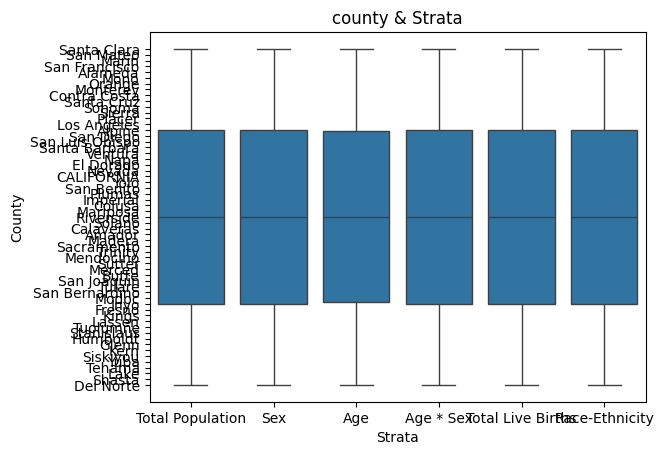

In [140]:
# county & strata
sns.boxplot(x='Strata', y='County', data=df)
plt.title("county & Strata")
plt.show()


The box plot shows the distribution of county across different strata categories.

The Blue boxes show the distribution of the data within each strata category

Line inside the box represents the median

In [151]:
import plotly.express as px

county_data = df['County'].value_counts().head(10).reset_index()
county_data.columns = ['County', 'Count']

fig = px.bar(
    county_data,
    x='Count',
    y='County',
    orientation='h',
    title='Top 10 Counties by Number of Records'
)

fig.show()

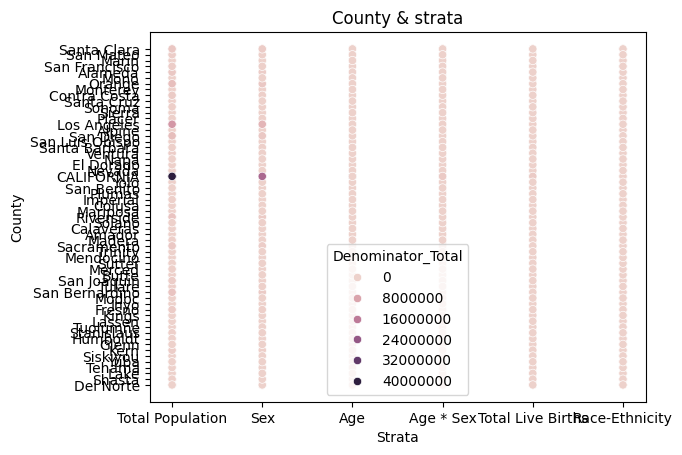

In [141]:
# County & strata
sns.scatterplot(x='Strata', y='County', data=df, hue='Denominator_Total')
plt.title("County & strata")
plt.show()


The scatter plot illustrates the distribution of health-related records across different strata and counties in california.
The each dots represents a data record,colour represent different denominator valies.Darker and lighter colors indicate different values.

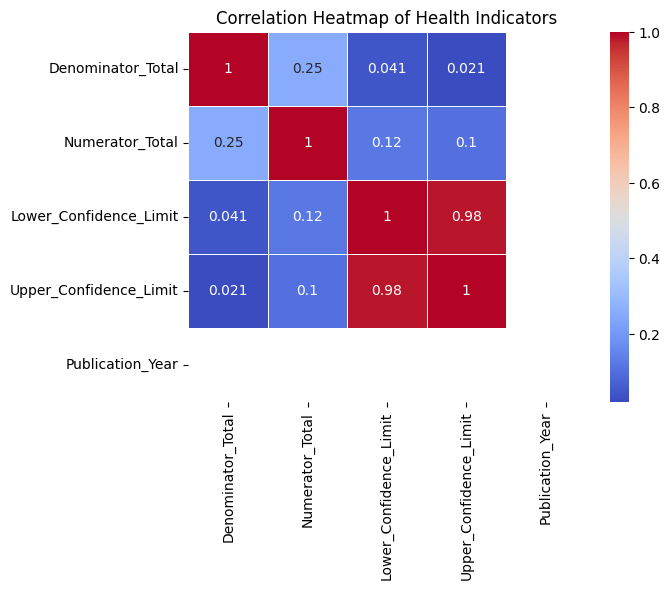

In [142]:
# Correlation matrix heatmap
corr_matrix = df[['Denominator_Total','Numerator_Total','Lower_Confidence_Limit','Upper_Confidence_Limit','Publication_Year']].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Health Indicators")
plt.show()


The correlation heatmap shows the relatioships between numerical health indicators.A strong positive correlation of 0.98 is observed between the lower confidence limit and upper confidence limit.other variables show relatively weak correlations.This analysis helps identify relationships between numerical variables and supports.

#5 *Insight Generation and Report*

## Conclusion

The analysis of the California County Health Status Profiles dataset revealed a comprehensive overview of various health indicators across the state's counties. The data, primarily from the `Publication_Year 2025` and `Healthy_People_Decade 2030`, provides a consistent snapshot or projection of health trends.

Key findings include a significant variability in `Denominator_Total` and `Numerator_Total` across different `Health_Indicator_Desc` and `County` values, highlighting the diverse health landscape within California. The preprocessing steps successfully addressed missing values and standardized the `Table` column, making the dataset more amenable to analysis. Outlier detection in `Denominator_Total` underscored the presence of counties or indicators with unusually large or small population bases, warranting further investigation.

The correlation analysis confirmed an expected strong positive relationship between the `Lower_Confidence_Limit` and `Upper_Confidence_Limit`, and a moderate positive correlation between `Denominator_Total` and `Numerator_Total`. This suggests that as the population base increases, the absolute number of health events generally follows, albeit not always proportionally across all indicators.

## Recommendations



*   **Targeted Outlier Analysis**: Investigate the 357 identified outliers in `Denominator_Total` to understand the specific counties, health indicators, and underlying reasons for these extreme values. This could reveal unique demographic or health-related situations.
*   **Deep Dive into Specific Health Indicators**: Focus on particular `Health_Indicator_Desc` values that show interesting patterns or significant variations across counties. For example, 'Deaths Due to All Causes' vs. more specific causes like 'Black Infant Mortality' could be explored in more detail.
*   **Advanced Visualization**: Refine visualizations to better represent categorical data and relationships. Consider treemaps for hierarchical data, or more interactive plots using libraries like Plotly (already imported) to explore county-level differences and health indicators more effectively. The current scatter plots and bar plots for categorical variables can be improved for readability and insight.
*   **Geospatial Analysis**: Since the data is county-specific, integrating geographical information could provide valuable insights into regional health disparities. Visualizing health indicators on a California map could reveal spatial clusters or trends.
*   **Longitudinal Analysis (if data available)**: Although the current dataset is limited to a single publication year, if historical data becomes available, a time-series analysis could reveal trends, seasonality, and the impact of health interventions over time.
*   **Feature Engineering**: Explore creating new features, such as rates per capita for `Numerator_Total` to `Denominator_Total`, or ratios between different health indicators to provide more normalized and comparable metrics.
*   **Statistical Modeling**: Depending on the specific questions, consider statistical models (e.g., regression analysis) to identify factors influencing certain health outcomes or to predict future trends based on the available indicators.